Task 8. Face Detection   

Run a Haar cascade face detector on your normal-light photo. If it misses a face or throws a false positive, zoom into that region and explain, from what you can see in the pixels (lighting, angle, occlusion), why you think the detector struggled there. 

In [1]:
import cv2
import matplotlib.pyplot as plt

In [3]:
img = cv2.imread("raw_captures/Sen_Bright.jpg")



gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [4]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

In [21]:
faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.5,
    minNeighbors=5,
    minSize=(40,40)
)

In [22]:
output = img.copy()

for (x, y, w, h) in faces:

    cv2.rectangle(
        output,
        (x, y),
        (x+w, y+h),
        (0,255,0),
        10
    )

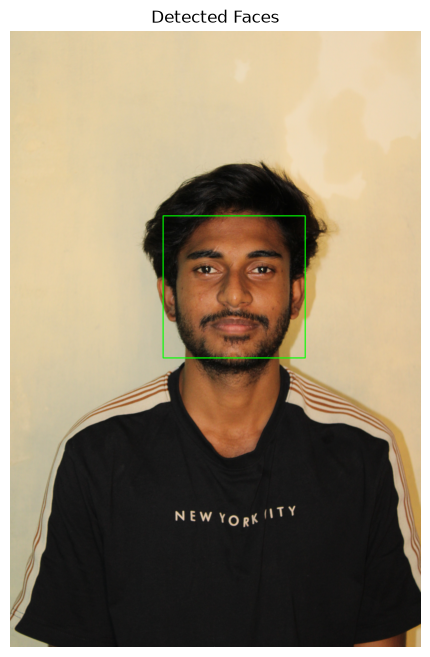

In [23]:
plt.figure(figsize=(10,8))

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("Detected Faces")
plt.axis("off")

plt.show()

Initially, I used a scaleFactor of 1.1 for the Haar Cascade face detector. The detector identified two faces: one was the actual face, while the second detection was a false positive on the neck region. This likely occurred because the neck area contained skin-colored pixels and shadow patterns that resembled some of the intensity features the Haar Cascade uses to identify faces.

I then increased the scaleFactor to 1.5. With this setting, the detector identified only the correct face, and the false positive disappeared. Increasing the scale factor reduced the number of image scales examined, making the detector more selective and eliminating the incorrect detection on the neck. The face remained large and clear enough to be detected correctly, while the neck region no longer satisfied the detector's criteria for a face.